# Chile Supply Chain: Data Quality and Diagnostic Visualizations

Non-network visualizations for the Chile mineral pipeline.
Run after `Chile_MainAn.ipynb` (requires CSVs in `Preliminary/`).

**Figures:**
1. Resource/Reserve Data Coverage
2. Copper Production Concentration
3. Supply Chain Structure and Connectivity
4. Export Destination Profile
5. Mine-to-Plant Link Distance Quality
6. Geographic Supply Chain Map (interactive, folium)
7. Port Share Comparison + Comtrade Cross-Validation


In [8]:
# %% 0. Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import os

# ── Paths ────────────────────────────────────────────────────────────────
BASE_DIR = "/Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile"
PRELIM   = os.path.join(BASE_DIR, "Preliminary")
OUT_DIR  = os.path.join(BASE_DIR, "Outputs")
os.makedirs(OUT_DIR, exist_ok=True)

# ── Style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 8.5,
    "axes.titlesize": 10.5,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f7",
    "axes.edgecolor": "#bbbbbb",
    "axes.linewidth": 0.6,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.35,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "text.color": "#2b2b2b",
    "axes.labelcolor": "#333333",
})

# Color palette: muted, high-contrast, colorblind-friendly
PAL = {
    "teal":     "#1b7a6e",
    "teal_lt":  "#6cc4a1",
    "brick":    "#c0392b",
    "brick_lt": "#e87461",
    "navy":     "#2c3e6b",
    "navy_lt":  "#6889b7",
    "amber":    "#d4940a",
    "amber_lt": "#f0c75e",
    "slate":    "#5c6370",
    "slate_lt": "#a0a8b4",
    "purple":   "#6c3483",
    "bg":       "#f7f7f7",
    "grid":     "#dddddd",
    "text":     "#2b2b2b",
    "text_sec": "#666666",
}

# Categorical palette (8 distinguishable colors)
CAT8 = ["#2c3e6b", "#1b7a6e", "#c0392b", "#d4940a",
        "#6c3483", "#d35400", "#16a085", "#7f8c8d"]

def add_source_note(fig, text, y=0.005):
    """Small attribution line at bottom."""
    fig.text(0.5, y, text, ha="center", fontsize=6.5, color="#999999", style="italic")

def thousands_fmt(x, _):
    if x >= 1000:
        return f"{x/1000:.0f}k" if x % 1000 == 0 else f"{x/1000:.1f}k"
    return f"{int(x)}"

# ── Load data ────────────────────────────────────────────────────────────
inv   = pd.read_csv(os.path.join(PRELIM, "Chile_Minerals_Inventory.csv"), low_memory=False)
links = pd.read_csv(os.path.join(PRELIM, "Chile_Mine_Plant_Links.csv"))
edges = pd.read_csv(os.path.join(PRELIM, "Chile_Supply_Chain_Edges.csv"))
exports = pd.read_csv(os.path.join(PRELIM, "Chile_Export_Destinations.csv"))
ports = pd.read_csv(os.path.join(PRELIM, "Chile_Ports.csv"))

# Derived columns
EXTRACTION_TYPES = ["Mine (active)", "Mine (idle)", "Prospect/Project", "Mine (USGS)"]
mines = inv[inv["FACILITY_TYPE"].isin(EXTRACTION_TYPES)].copy()

comm_col = "COMMODITY_LIST_STR" if "COMMODITY_LIST_STR" in inv.columns else "ALL_COMMODITIES_RAW"


# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1: RESOURCE / RESERVE DATA COVERAGE
# ═══════════════════════════════════════════════════════════════════════════



Saved: /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Outputs/Missing_Data_Analysis.png


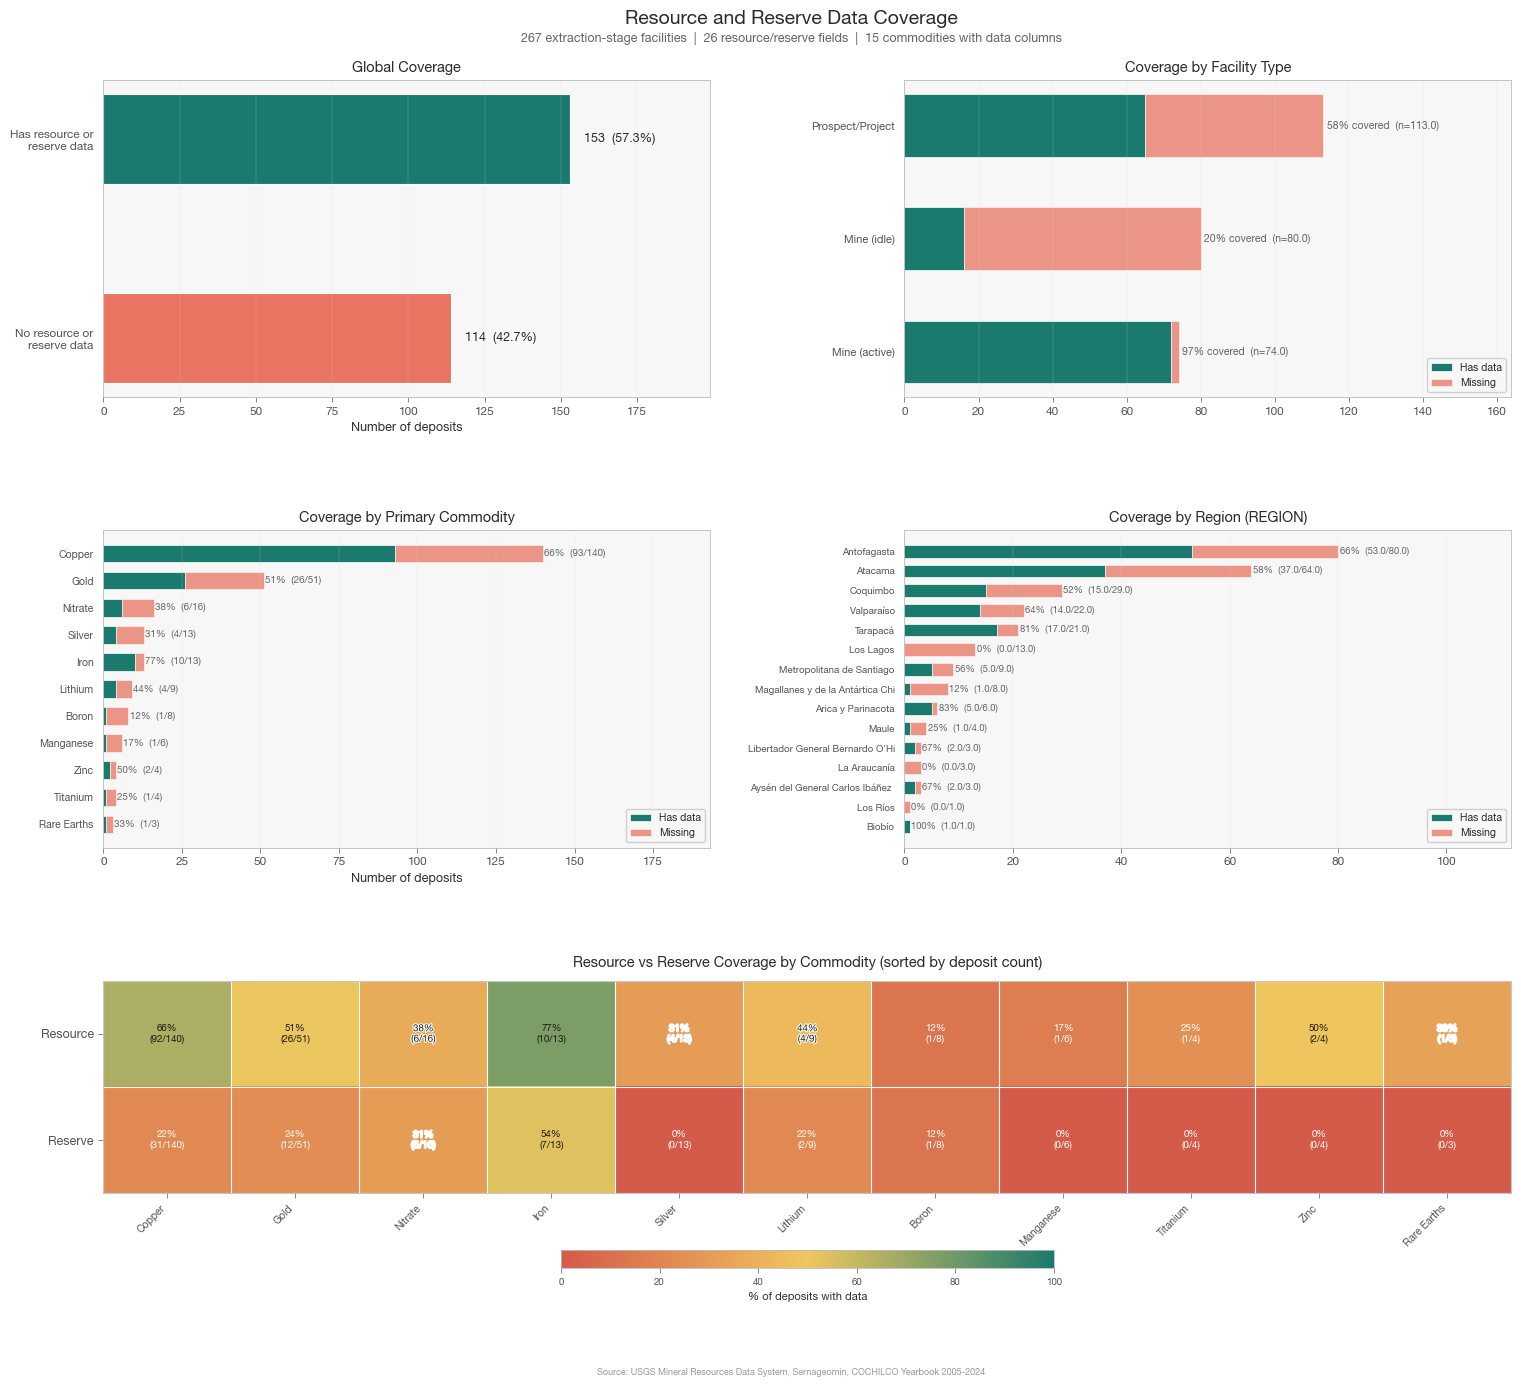

In [9]:
# %% 1. Missing resource/reserve data analysis

res_cols = sorted([c for c in inv.columns if c.endswith(("_Resource", "_Reserve"))])
commodities_with_data = sorted(set(c.rsplit("_", 1)[0] for c in res_cols))
mines["has_any_resource"] = mines[res_cols].notna().any(axis=1)

def has_primary_resource(row):
    pc = row.get("PRIMARY_COMMODITY", "")
    if pd.isna(pc) or pc == "":
        return False
    return any(
        col in inv.columns and pd.notna(row.get(col))
        for col in [f"{pc}_Resource", f"{pc}_Reserve"]
    )

mines["has_primary_resource"] = mines.apply(has_primary_resource, axis=1)

COL_HAS  = PAL["teal"]
COL_MISS = PAL["brick_lt"]

fig = plt.figure(figsize=(16, 14))
fig.suptitle("Resource and Reserve Data Coverage",
             fontsize=14, fontweight="bold", y=0.98, color=PAL["text"])
fig.text(0.5, 0.957,
         f"{len(mines)} extraction-stage facilities  |  "
         f"{len(res_cols)} resource/reserve fields  |  "
         f"{len(commodities_with_data)} commodities with data columns",
         ha="center", fontsize=9, color=PAL["text_sec"])

gs = gridspec.GridSpec(3, 2, hspace=0.42, wspace=0.32,
                       left=0.07, right=0.95, top=0.93, bottom=0.06)

# ── Panel 0: Global summary ──────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
n_has  = mines["has_any_resource"].sum()
n_miss = (~mines["has_any_resource"]).sum()
labels = ["Has resource or\nreserve data", "No resource or\nreserve data"]
vals   = [n_has, n_miss]
colors = [COL_HAS, COL_MISS]

bars = ax0.barh(labels, vals, color=colors, edgecolor="white", linewidth=0.8, height=0.45)
for bar, val in zip(bars, vals):
    pct = val / len(mines) * 100
    ax0.text(bar.get_width() + max(vals)*0.03, bar.get_y() + bar.get_height()/2,
             f"{val}  ({pct:.1f}%)", va="center", fontsize=9, fontweight="bold",
             color=PAL["text"])
ax0.set_xlim(0, max(vals) * 1.3)
ax0.set_title("Global Coverage")
ax0.set_xlabel("Number of deposits")
ax0.invert_yaxis()
ax0.grid(axis="x", alpha=0.4)
ax0.tick_params(left=False)

# ── Panel 1: Coverage by facility type ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
type_stats = mines.groupby("FACILITY_TYPE").agg(
    total=("has_any_resource", "size"),
    has_data=("has_any_resource", "sum")
).sort_values("total", ascending=True)
type_stats["missing"] = type_stats["total"] - type_stats["has_data"]
type_stats["pct"] = (type_stats["has_data"] / type_stats["total"] * 100).round(1)

y = range(len(type_stats))
ax1.barh(y, type_stats["has_data"], color=COL_HAS, label="Has data",
         height=0.55, edgecolor="white", linewidth=0.5)
ax1.barh(y, type_stats["missing"], left=type_stats["has_data"],
         color=COL_MISS, label="Missing", height=0.55, alpha=0.75,
         edgecolor="white", linewidth=0.5)
ax1.set_yticks(y)
ax1.set_yticklabels(type_stats.index, fontsize=8)
for i, (_, row) in enumerate(type_stats.iterrows()):
    ax1.text(row["total"] + 1, i,
             f'{row["pct"]:.0f}% covered  (n={row["total"]})',
             va="center", fontsize=7.5, color=PAL["text_sec"])
ax1.set_xlim(0, type_stats["total"].max() * 1.45)
ax1.set_title("Coverage by Facility Type")
ax1.legend(loc="lower right", fontsize=7.5, framealpha=0.9, edgecolor="#cccccc")
ax1.grid(axis="x", alpha=0.4)
ax1.tick_params(left=False)

# ── Panel 2: Coverage by primary commodity ────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
all_comms = mines["PRIMARY_COMMODITY"].dropna().unique()
comm_coverage = []
for comm in sorted(all_comms):
    subset = mines[mines["PRIMARY_COMMODITY"] == comm]
    total = len(subset)
    res_c, rev_c = f"{comm}_Resource", f"{comm}_Reserve"
    n_res = subset[res_c].notna().sum() if res_c in subset.columns else 0
    n_rev = subset[rev_c].notna().sum() if rev_c in subset.columns else 0
    n_either = subset.apply(
        lambda r: pd.notna(r.get(res_c)) or pd.notna(r.get(rev_c)), axis=1
    ).sum() if (res_c in subset.columns or rev_c in subset.columns) else 0
    comm_coverage.append({
        "commodity": comm, "total": total,
        "has_either": int(n_either), "missing": total - int(n_either),
        "pct": round(n_either / total * 100, 1) if total > 0 else 0,
        "has_resource": int(n_res), "has_reserve": int(n_rev),
    })

cc = pd.DataFrame(comm_coverage).sort_values("total", ascending=True)
cc = cc[cc["total"] >= 1]
y = range(len(cc))
ax2.barh(y, cc["has_either"], color=COL_HAS, label="Has data",
         height=0.65, edgecolor="white", linewidth=0.5)
ax2.barh(y, cc["missing"], left=cc["has_either"],
         color=COL_MISS, label="Missing", height=0.65, alpha=0.75,
         edgecolor="white", linewidth=0.5)
ax2.set_yticks(y)
ax2.set_yticklabels(cc["commodity"], fontsize=7.5)
for i, (_, row) in enumerate(cc.iterrows()):
    ax2.text(row["total"] + 0.4, i,
             f'{row["pct"]:.0f}%  ({row["has_either"]}/{row["total"]})',
             va="center", fontsize=7, color=PAL["text_sec"])
ax2.set_xlim(0, cc["total"].max() * 1.38)
ax2.set_title("Coverage by Primary Commodity")
ax2.set_xlabel("Number of deposits")
ax2.legend(loc="lower right", fontsize=7.5, framealpha=0.9, edgecolor="#cccccc")
ax2.grid(axis="x", alpha=0.4)
ax2.tick_params(left=False)

# ── Panel 3: Coverage by region ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
reg_col = next(
    (c for c in ["REGION", "NOMBRE_REGION", "ADM1"]
     if c in mines.columns and mines[c].notna().sum() > 10),
    None
)

if reg_col:
    reg_stats = mines.groupby(reg_col).agg(
        total=("has_any_resource", "size"),
        has_data=("has_any_resource", "sum")
    ).sort_values("total", ascending=True)
    reg_stats["missing"] = reg_stats["total"] - reg_stats["has_data"]
    reg_stats["pct"] = (reg_stats["has_data"] / reg_stats["total"] * 100).round(1)

    labels_r = [str(r)[:32] for r in reg_stats.index]
    y = range(len(reg_stats))
    ax3.barh(y, reg_stats["has_data"], color=COL_HAS, label="Has data",
             height=0.65, edgecolor="white", linewidth=0.5)
    ax3.barh(y, reg_stats["missing"], left=reg_stats["has_data"],
             color=COL_MISS, label="Missing", height=0.65, alpha=0.75,
             edgecolor="white", linewidth=0.5)
    ax3.set_yticks(y)
    ax3.set_yticklabels(labels_r, fontsize=7)
    for i, (_, row) in enumerate(reg_stats.iterrows()):
        ax3.text(row["total"] + 0.3, i,
                 f'{row["pct"]:.0f}%  ({row["has_data"]}/{row["total"]})',
                 va="center", fontsize=6.8, color=PAL["text_sec"])
    ax3.set_xlim(0, reg_stats["total"].max() * 1.4)
    ax3.set_title(f"Coverage by Region ({reg_col})")
    ax3.legend(loc="lower right", fontsize=7.5, framealpha=0.9, edgecolor="#cccccc")
else:
    ax3.text(0.5, 0.5, "No region column found",
             ha="center", va="center", transform=ax3.transAxes, color=PAL["text_sec"])
    ax3.set_title("Coverage by Region")
ax3.grid(axis="x", alpha=0.4)
ax3.tick_params(left=False)

# ── Panel 4: Heatmap ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
heat_data = []
for comm in sorted(all_comms):
    subset = mines[mines["PRIMARY_COMMODITY"] == comm]
    total = len(subset)
    if total == 0:
        continue
    res_c, rev_c = f"{comm}_Resource", f"{comm}_Reserve"
    n_res = subset[res_c].notna().sum() if res_c in subset.columns else 0
    n_rev = subset[rev_c].notna().sum() if rev_c in subset.columns else 0
    heat_data.append({
        "commodity": comm, "total": total,
        "Resource (%)": round(n_res / total * 100, 1),
        "Reserve (%)": round(n_rev / total * 100, 1),
        "Resource (n)": int(n_res), "Reserve (n)": int(n_rev),
    })

hdf = pd.DataFrame(heat_data).sort_values("total", ascending=False)
matrix = hdf[["Resource (%)", "Reserve (%)"]].values

# Custom diverging colormap: brick (0%) -> amber (50%) -> teal (100%)
from matplotlib.colors import LinearSegmentedColormap
cmap_custom = LinearSegmentedColormap.from_list(
    "coverage", ["#d45a4a", "#f0c75e", "#1b7a6e"], N=256)

im = ax4.imshow(matrix.T, aspect="auto", cmap=cmap_custom, vmin=0, vmax=100)
ax4.set_xticks(range(len(hdf)))
ax4.set_xticklabels(hdf["commodity"], rotation=45, ha="right", fontsize=7.5)
ax4.set_yticks([0, 1])
ax4.set_yticklabels(["Resource", "Reserve"], fontsize=9)

for i in range(len(hdf)):
    for j, col_type in enumerate(["Resource", "Reserve"]):
        pct = matrix[i, j]
        n = hdf.iloc[i][f"{col_type} (n)"]
        total = hdf.iloc[i]["total"]
        color = "white" if pct < 35 else "#1a1a1a"
        ax4.text(i, j, f"{pct:.0f}%\n({n}/{total})",
                 ha="center", va="center", fontsize=7, color=color, fontweight="bold",
                 path_effects=[pe.withStroke(linewidth=1.5, foreground="white")] if pct > 30 and pct < 50 else [])

cbar = fig.colorbar(im, ax=ax4, orientation="horizontal", pad=0.18, shrink=0.35, aspect=28)
cbar.set_label("% of deposits with data", fontsize=8)
cbar.ax.tick_params(labelsize=7)
ax4.set_title("Resource vs Reserve Coverage by Commodity (sorted by deposit count)", pad=10)

# Thin cell borders
for i in range(len(hdf) + 1):
    ax4.axvline(i - 0.5, color="white", linewidth=0.8)
for j in range(3):
    ax4.axhline(j - 0.5, color="white", linewidth=0.8)

add_source_note(fig, "Source: USGS Mineral Resources Data System, Sernageomin, COCHILCO Yearbook 2005-2024")

out1 = os.path.join(OUT_DIR, "Missing_Data_Analysis.png")
fig.savefig(out1, dpi=200, bbox_inches="tight")
print(f"Saved: {out1}")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2: COPPER PRODUCTION CONCENTRATION
# ═══════════════════════════════════════════════════════════════════════════


Saved: /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Outputs/Cu_Production_Concentration.png


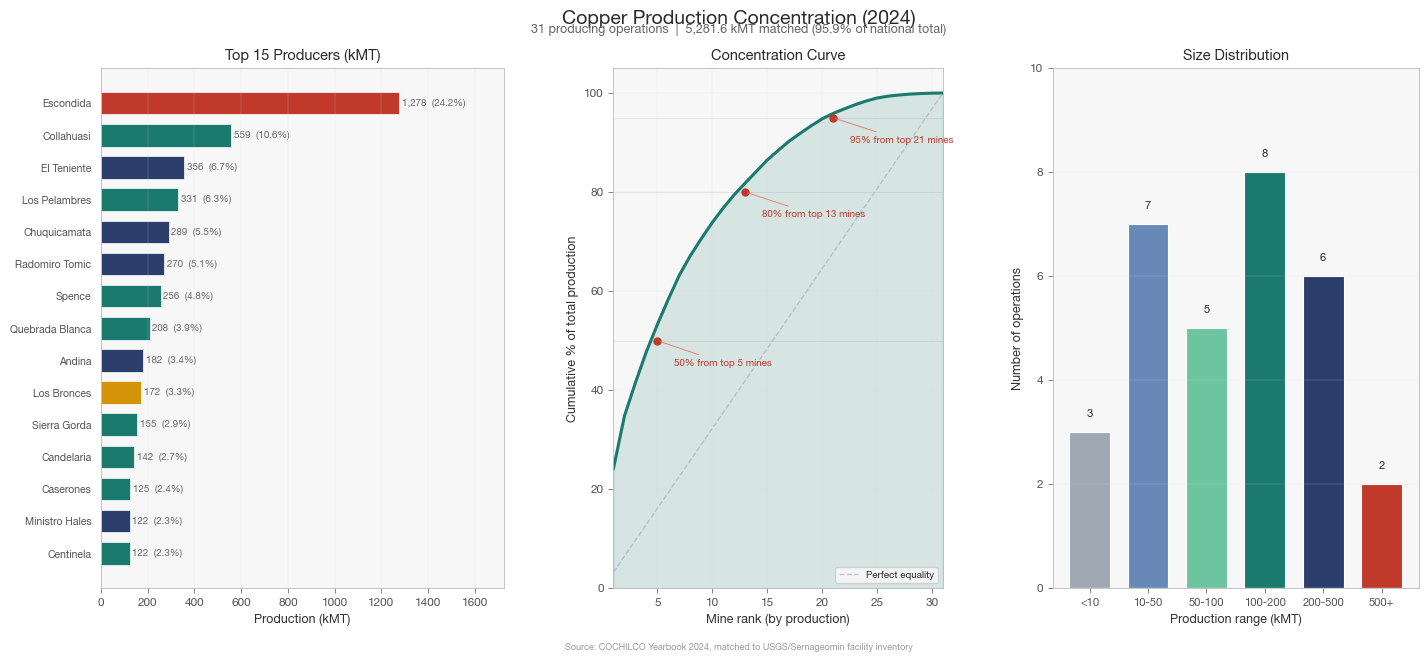

In [10]:
# %% 2. Production concentration

cu_prod = inv[inv["COCHILCO_CU_2024_KMT"].notna() & (inv["COCHILCO_CU_2024_KMT"] > 0)].copy()
cu_prod = cu_prod.sort_values("COCHILCO_CU_2024_KMT", ascending=False).reset_index(drop=True)
cu_total_matched = cu_prod["COCHILCO_CU_2024_KMT"].sum()
cu_prod["cumulative_pct"] = cu_prod["COCHILCO_CU_2024_KMT"].cumsum() / cu_total_matched * 100
cu_prod["rank"] = range(1, len(cu_prod) + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 6.5),
                         gridspec_kw={"width_ratios": [1.1, 0.9, 1.0], "wspace": 0.30})
fig.suptitle("Copper Production Concentration (2024)",
             fontsize=14, fontweight="bold", y=0.99, color=PAL["text"])
fig.text(0.5, 0.955,
         f"{len(cu_prod)} producing operations  |  "
         f"{cu_total_matched:,.1f} kMT matched ({cu_total_matched/5506*100:.1f}% of national total)",
         ha="center", fontsize=9, color=PAL["text_sec"])

# ── Panel A: Top-15 bar chart ─────────────────────────────────────────────
ax = axes[0]
top15 = cu_prod.head(15).copy()
# Shorten Codelco division names for display
top15["label"] = top15["FACILITY_NAME"].str.replace("División ", "", regex=False)
top15 = top15.iloc[::-1]  # reverse for horizontal bars

colors_bar = []
for _, row in top15.iterrows():
    op = str(row.get("OPERATOR_NAME", "")).lower()
    if "codelco" in op:
        colors_bar.append(PAL["navy"])
    elif "bhp" in op or "escondida" in op:
        colors_bar.append(PAL["brick"])
    elif "anglo" in op:
        colors_bar.append(PAL["amber"])
    elif "teck" in op:
        colors_bar.append(PAL["purple"])
    else:
        colors_bar.append(PAL["teal"])

y_pos = range(len(top15))
bars = ax.barh(y_pos, top15["COCHILCO_CU_2024_KMT"], color=colors_bar,
               edgecolor="white", linewidth=0.5, height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(top15["label"], fontsize=7.5)
for i, (_, row) in enumerate(top15.iterrows()):
    val = row["COCHILCO_CU_2024_KMT"]
    pct = val / cu_total_matched * 100
    ax.text(val + 10, i, f"{val:,.0f}  ({pct:.1f}%)",
            va="center", fontsize=7, color=PAL["text_sec"])
ax.set_xlim(0, top15["COCHILCO_CU_2024_KMT"].max() * 1.35)
ax.set_title("Top 15 Producers (kMT)")
ax.set_xlabel("Production (kMT)")
ax.grid(axis="x", alpha=0.4)
ax.tick_params(left=False)

# ── Panel B: Cumulative concentration curve ───────────────────────────────
ax = axes[1]
x = cu_prod["rank"].values
y_cum = cu_prod["cumulative_pct"].values

ax.fill_between(x, y_cum, alpha=0.15, color=PAL["teal"])
ax.plot(x, y_cum, color=PAL["teal"], linewidth=2.2)

# Equality line
ax.plot([1, len(cu_prod)], [100/len(cu_prod), 100], color=PAL["slate_lt"],
        linestyle="--", linewidth=1, alpha=0.6, label="Perfect equality")

# Annotate key thresholds
for threshold in [50, 80, 95]:
    idx = np.searchsorted(y_cum, threshold)
    if idx < len(x):
        ax.axhline(threshold, color=PAL["grid"], linewidth=0.5, zorder=0)
        ax.plot(x[idx], threshold, "o", color=PAL["brick"], markersize=5, zorder=3)
        ax.annotate(f"{threshold}% from top {x[idx]} mines",
                    xy=(x[idx], threshold), xytext=(x[idx]+1.5, threshold-5),
                    fontsize=7, color=PAL["brick"],
                    arrowprops=dict(arrowstyle="-", color=PAL["brick_lt"], lw=0.6))

ax.set_xlabel("Mine rank (by production)")
ax.set_ylabel("Cumulative % of total production")
ax.set_title("Concentration Curve")
ax.set_xlim(1, len(cu_prod))
ax.set_ylim(0, 105)
ax.legend(loc="lower right", fontsize=7, framealpha=0.9, edgecolor="#cccccc")
ax.grid(alpha=0.4)

# ── Panel C: Size distribution histogram ──────────────────────────────────
ax = axes[2]
prod_vals = cu_prod["COCHILCO_CU_2024_KMT"].values

bins = [0, 10, 50, 100, 200, 500, 1500]
bin_labels = ["<10", "10-50", "50-100", "100-200", "200-500", "500+"]
counts, _ = np.histogram(prod_vals, bins=bins)

bar_colors = [PAL["slate_lt"], PAL["navy_lt"], PAL["teal_lt"],
              PAL["teal"], PAL["navy"], PAL["brick"]]

x_pos = range(len(counts))
bars = ax.bar(x_pos, counts, color=bar_colors[:len(counts)],
              edgecolor="white", linewidth=0.8, width=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels, fontsize=8)
for bar, val in zip(bars, counts):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha="center", fontsize=8, fontweight="bold", color=PAL["text"])
ax.set_xlabel("Production range (kMT)")
ax.set_ylabel("Number of operations")
ax.set_title("Size Distribution")
ax.grid(axis="y", alpha=0.4)
ax.set_ylim(0, max(counts) * 1.25)

plt.subplots_adjust(top=0.90, bottom=0.10)
add_source_note(fig, "Source: COCHILCO Yearbook 2024, matched to USGS/Sernageomin facility inventory")

out2 = os.path.join(OUT_DIR, "Cu_Production_Concentration.png")
fig.savefig(out2, dpi=200, bbox_inches="tight")
print(f"Saved: {out2}")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3: SUPPLY CHAIN STRUCTURE AND CONNECTIVITY
# ═══════════════════════════════════════════════════════════════════════════


Saved: /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Outputs/Supply_Chain_Structure.png


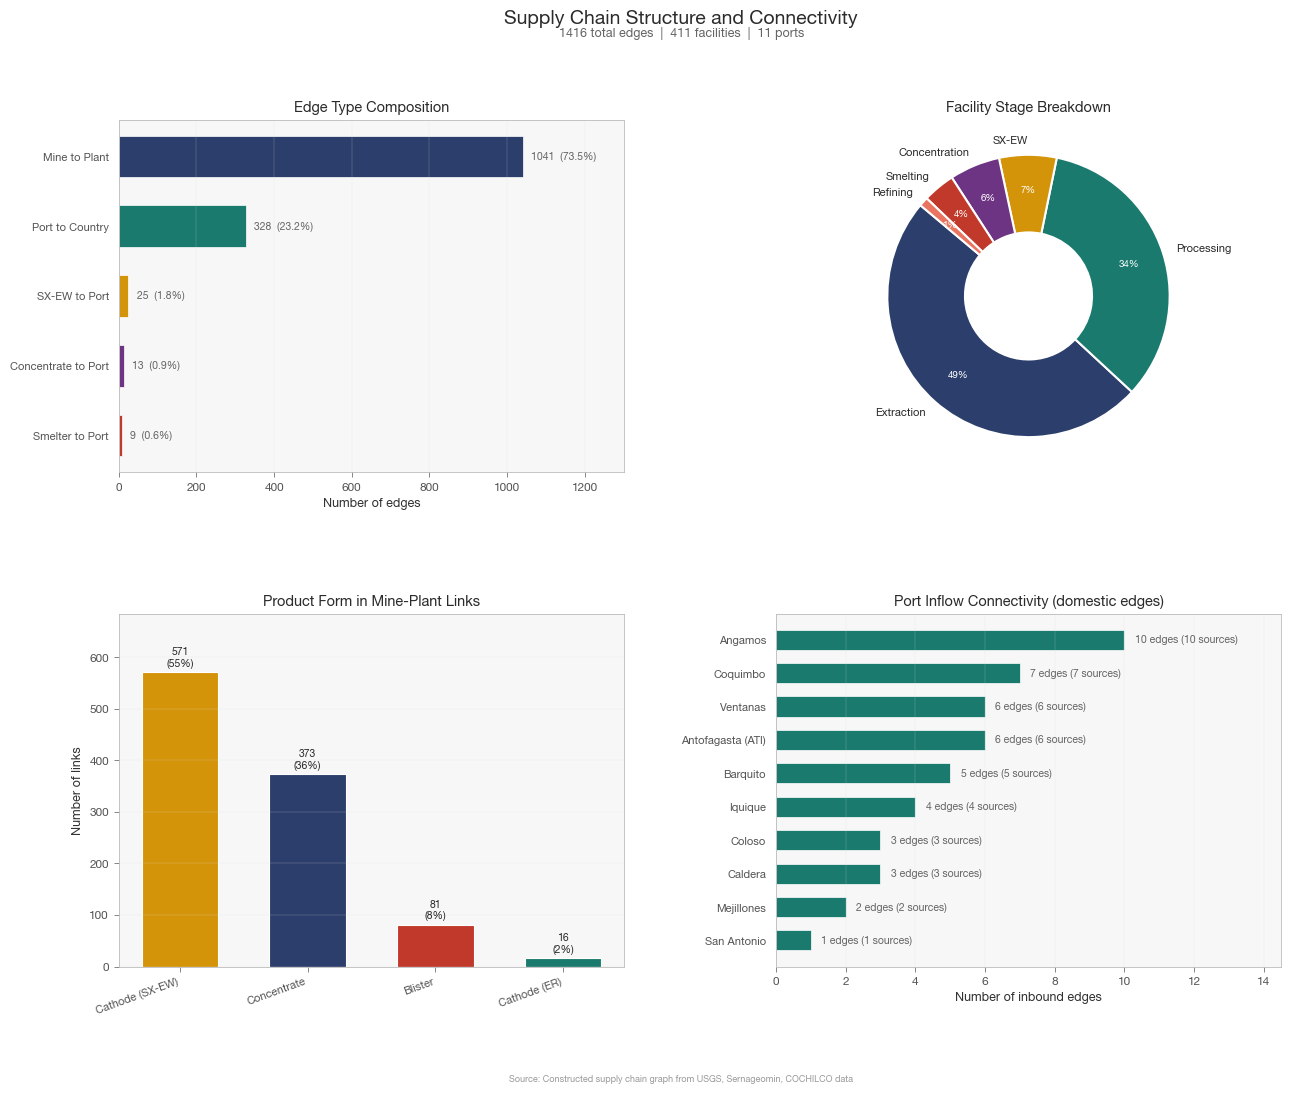

In [11]:
# %% 3. Supply chain structure

fig, axes = plt.subplots(2, 2, figsize=(15, 11),
                         gridspec_kw={"hspace": 0.40, "wspace": 0.30})
fig.suptitle("Supply Chain Structure and Connectivity",
             fontsize=14, fontweight="bold", y=0.98, color=PAL["text"])
fig.text(0.5, 0.955,
         f"{len(edges)} total edges  |  {inv['FACILITY_NAME'].nunique()} facilities  |  "
         f"{len(ports)} ports",
         ha="center", fontsize=9, color=PAL["text_sec"])

# ── Panel A: Edge type composition ────────────────────────────────────────
ax = axes[0, 0]
edge_counts = edges["EDGE_TYPE"].value_counts()
edge_labels = {
    "mine_to_plant":       "Mine to Plant",
    "port_to_country":     "Port to Country",
    "sxew_to_port":        "SX-EW to Port",
    "concentrate_to_port": "Concentrate to Port",
    "smelter_to_port":     "Smelter to Port",
}
edge_colors = {
    "mine_to_plant":       PAL["navy"],
    "port_to_country":     PAL["teal"],
    "sxew_to_port":        PAL["amber"],
    "concentrate_to_port": PAL["purple"],
    "smelter_to_port":     PAL["brick"],
}

sorted_types = edge_counts.index.tolist()
counts_list = [edge_counts[et] for et in sorted_types]
labels_list = [edge_labels.get(et, et) for et in sorted_types]
colors_list = [edge_colors.get(et, PAL["slate"]) for et in sorted_types]

bars = ax.barh(range(len(sorted_types)), counts_list, color=colors_list,
               edgecolor="white", linewidth=0.5, height=0.6)
ax.set_yticks(range(len(sorted_types)))
ax.set_yticklabels(labels_list, fontsize=8)
for i, (bar, val) in enumerate(zip(bars, counts_list)):
    pct = val / len(edges) * 100
    ax.text(bar.get_width() + max(counts_list)*0.02, i,
            f"{val}  ({pct:.1f}%)", va="center", fontsize=7.5, color=PAL["text_sec"])
ax.set_xlim(0, max(counts_list) * 1.25)
ax.set_title("Edge Type Composition")
ax.set_xlabel("Number of edges")
ax.grid(axis="x", alpha=0.4)
ax.tick_params(left=False)
ax.invert_yaxis()

# ── Panel B: Facility stage breakdown ─────────────────────────────────────
ax = axes[0, 1]
if "CHAIN_STAGE" in inv.columns:
    stage_counts = inv["CHAIN_STAGE"].value_counts()
    stage_order = ["extraction", "processing", "sx_ew", "concentration", "smelting", "refining", "other"]
    stage_labels_map = {
        "extraction": "Extraction", "processing": "Processing",
        "sx_ew": "SX-EW", "concentration": "Concentration",
        "smelting": "Smelting", "refining": "Refining", "other": "Other",
    }
    stage_colors = {
        "extraction": PAL["navy"], "processing": PAL["teal"],
        "sx_ew": PAL["amber"], "concentration": PAL["purple"],
        "smelting": PAL["brick"], "refining": PAL["brick_lt"], "other": PAL["slate_lt"],
    }
    present = [s for s in stage_order if s in stage_counts.index]
    vals_s = [stage_counts[s] for s in present]
    labs_s = [stage_labels_map.get(s, s) for s in present]
    cols_s = [stage_colors.get(s, PAL["slate"]) for s in present]

    wedges, texts, autotexts = ax.pie(
        vals_s, labels=labs_s, colors=cols_s, autopct="%1.0f%%",
        startangle=140, pctdistance=0.75,
        wedgeprops=dict(width=0.55, edgecolor="white", linewidth=1.5),
        textprops=dict(fontsize=8),
    )
    for at in autotexts:
        at.set_fontsize(7)
        at.set_color("white")
        at.set_fontweight("bold")
    ax.set_title("Facility Stage Breakdown")
else:
    ax.text(0.5, 0.5, "CHAIN_STAGE not found", ha="center", va="center",
            transform=ax.transAxes, color=PAL["text_sec"])

# ── Panel C: Product form in mine-plant links ─────────────────────────────
ax = axes[1, 0]
if "PRODUCT_FORM" in links.columns:
    pf_counts = links["PRODUCT_FORM"].value_counts()
    pf_labels = {
        "cathode_sxew": "Cathode (SX-EW)",
        "concentrate":  "Concentrate",
        "blister":      "Blister",
        "cathode_er":   "Cathode (ER)",
        "unknown":      "Unknown",
    }
    pf_colors = {
        "cathode_sxew": PAL["amber"],
        "concentrate":  PAL["navy"],
        "blister":      PAL["brick"],
        "cathode_er":   PAL["teal"],
        "unknown":      PAL["slate_lt"],
    }
    pf_types = pf_counts.index.tolist()
    pf_vals  = pf_counts.values
    pf_labs  = [pf_labels.get(p, p) for p in pf_types]
    pf_cols  = [pf_colors.get(p, PAL["slate"]) for p in pf_types]

    bars = ax.bar(range(len(pf_types)), pf_vals, color=pf_cols,
                  edgecolor="white", linewidth=0.8, width=0.6)
    ax.set_xticks(range(len(pf_types)))
    ax.set_xticklabels(pf_labs, fontsize=8, rotation=20, ha="right")
    for bar, val in zip(bars, pf_vals):
        pct = val / len(links) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(pf_vals)*0.02,
                f"{val}\n({pct:.0f}%)", ha="center", fontsize=7.5, color=PAL["text"])
    ax.set_title("Product Form in Mine-Plant Links")
    ax.set_ylabel("Number of links")
    ax.grid(axis="y", alpha=0.4)
    ax.set_ylim(0, max(pf_vals) * 1.2)

# ── Panel D: Port connectivity ────────────────────────────────────────────
ax = axes[1, 1]
port_edges = edges[edges["EDGE_TYPE"].isin(
    ["sxew_to_port", "concentrate_to_port", "smelter_to_port"])]

if len(port_edges) > 0:
    port_inflows = port_edges.groupby("TO_NAME").agg(
        n_edges=("FROM_NAME", "count"),
        n_sources=("FROM_NAME", "nunique"),
    ).sort_values("n_edges", ascending=True)

    y = range(len(port_inflows))
    bars = ax.barh(y, port_inflows["n_edges"], color=PAL["teal"],
                   edgecolor="white", linewidth=0.5, height=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(port_inflows.index, fontsize=8)
    for i, (_, row) in enumerate(port_inflows.iterrows()):
        ax.text(row["n_edges"] + 0.3, i,
                f'{row["n_edges"]} edges ({row["n_sources"]} sources)',
                va="center", fontsize=7.5, color=PAL["text_sec"])
    ax.set_xlim(0, port_inflows["n_edges"].max() * 1.45)
    ax.set_title("Port Inflow Connectivity (domestic edges)")
    ax.set_xlabel("Number of inbound edges")
    ax.grid(axis="x", alpha=0.4)
    ax.tick_params(left=False)

add_source_note(fig, "Source: Constructed supply chain graph from USGS, Sernageomin, COCHILCO data")

out3 = os.path.join(OUT_DIR, "Supply_Chain_Structure.png")
fig.savefig(out3, dpi=200, bbox_inches="tight")
print(f"Saved: {out3}")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4: EXPORT DESTINATION PROFILE
# ═══════════════════════════════════════════════════════════════════════════


Saved: /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Outputs/Export_Destination_Profile.png


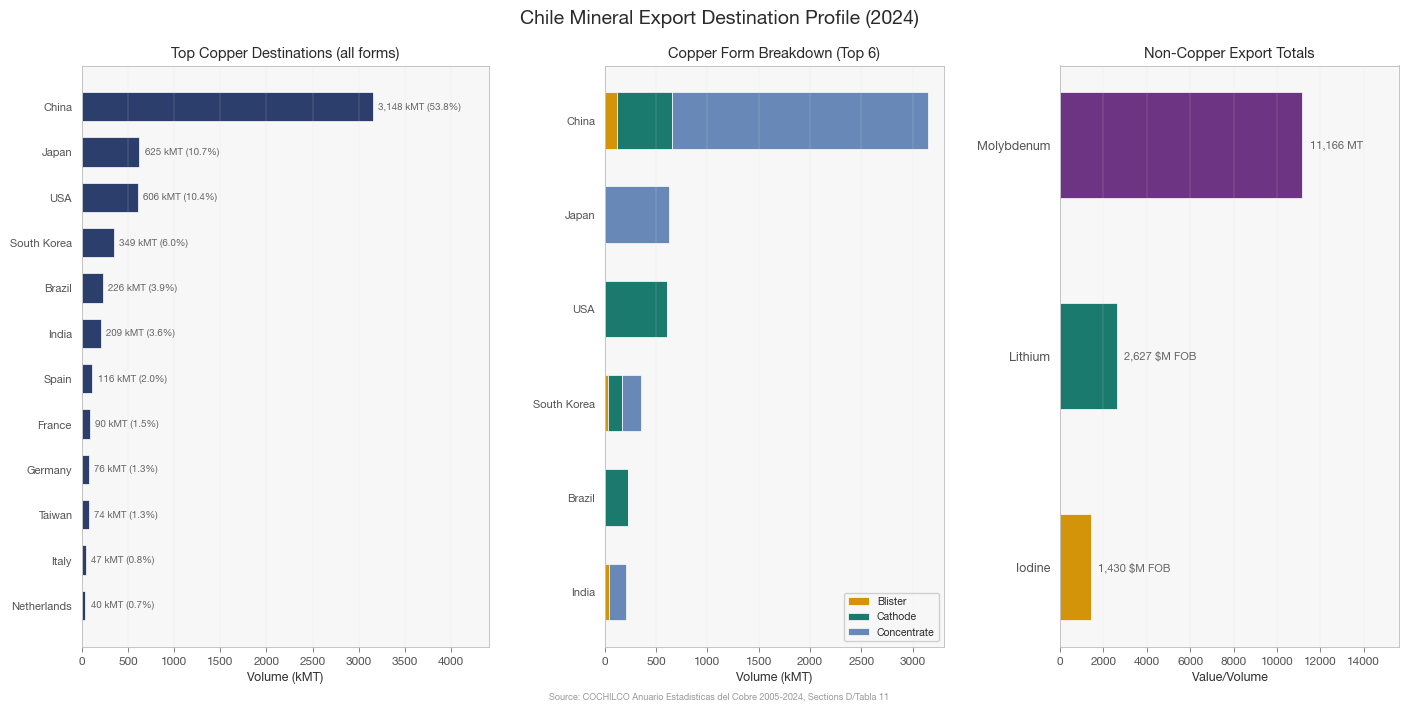

In [12]:
# %% 4. Export destinations

fig, axes = plt.subplots(1, 3, figsize=(17, 7),
                         gridspec_kw={"width_ratios": [1.2, 1.0, 1.0], "wspace": 0.32})
fig.suptitle("Chile Mineral Export Destination Profile (2024)",
             fontsize=14, fontweight="bold", y=0.99, color=PAL["text"])

# ── Panel A: Top destinations for copper (all forms combined) ─────────────
ax = axes[0]
cu_exports = exports[exports["COMMODITIES"] == "Copper"].copy()
if len(cu_exports) > 0 and "DESTINATION_TOTAL" in cu_exports.columns:
    # Group by country, sum the destination_total (deduplicate across port splits)
    cu_by_country = cu_exports.groupby("TO_NAME").agg(
        total=("DESTINATION_TOTAL", "first"),  # same value per country-product
        n_ports=("FROM_NAME", "nunique"),
    )
    # Actually, DESTINATION_TOTAL is per product form; need to aggregate properly
    cu_by_country = cu_exports.drop_duplicates(
        subset=["TO_NAME", "PRODUCT_FORM"]
    ).groupby("TO_NAME")["DESTINATION_TOTAL"].sum().sort_values(ascending=False)

    top12 = cu_by_country.head(12)
    top12_rev = top12.iloc[::-1]  # reverse for horizontal bar

    total_cu_export = cu_by_country.sum()
    bars = ax.barh(range(len(top12_rev)), top12_rev.values, color=PAL["navy"],
                   edgecolor="white", linewidth=0.5, height=0.65)
    ax.set_yticks(range(len(top12_rev)))
    ax.set_yticklabels(top12_rev.index, fontsize=8)
    for i, (country, val) in enumerate(top12_rev.items()):
        pct = val / total_cu_export * 100
        ax.text(val + total_cu_export*0.01, i,
                f"{val:,.0f} kMT ({pct:.1f}%)",
                va="center", fontsize=7, color=PAL["text_sec"])
    ax.set_xlim(0, top12_rev.max() * 1.4)
    ax.set_title("Top Copper Destinations (all forms)")
    ax.set_xlabel("Volume (kMT)")
    ax.grid(axis="x", alpha=0.4)
    ax.tick_params(left=False)

# ── Panel B: Copper form breakdown for top 6 ─────────────────────────────
ax = axes[1]
if len(cu_exports) > 0:
    top6_countries = cu_by_country.head(6).index.tolist()
    cu_top6 = cu_exports[cu_exports["TO_NAME"].isin(top6_countries)].copy()
    form_by_country = cu_top6.drop_duplicates(
        subset=["TO_NAME", "PRODUCT_FORM"]
    ).pivot_table(
        index="TO_NAME", columns="PRODUCT_FORM",
        values="DESTINATION_TOTAL", aggfunc="sum", fill_value=0
    )
    # Reorder rows by total
    form_by_country = form_by_country.loc[
        form_by_country.sum(axis=1).sort_values(ascending=True).index]

    form_colors = {
        "concentrate": PAL["navy_lt"],
        "cathode":     PAL["teal"],
        "blister":     PAL["amber"],
    }
    left = np.zeros(len(form_by_country))
    for col in form_by_country.columns:
        color = form_colors.get(col, PAL["slate_lt"])
        ax.barh(range(len(form_by_country)), form_by_country[col], left=left,
                color=color, edgecolor="white", linewidth=0.5, height=0.6,
                label=col.capitalize())
        left += form_by_country[col].values

    ax.set_yticks(range(len(form_by_country)))
    ax.set_yticklabels(form_by_country.index, fontsize=8)
    ax.set_title("Copper Form Breakdown (Top 6)")
    ax.set_xlabel("Volume (kMT)")
    ax.legend(loc="lower right", fontsize=7.5, framealpha=0.9, edgecolor="#cccccc")
    ax.grid(axis="x", alpha=0.4)
    ax.tick_params(left=False)

# ── Panel C: Non-copper exports ───────────────────────────────────────────
ax = axes[2]
non_cu = exports[exports["COMMODITIES"] != "Copper"].copy()
if len(non_cu) > 0:
    comm_totals = non_cu.drop_duplicates(
        subset=["TO_NAME", "COMMODITIES"]
    ).groupby("COMMODITIES")["DESTINATION_TOTAL"].sum().sort_values(ascending=True)

    comm_colors_map = {
        "Molybdenum": PAL["purple"],
        "Lithium":    PAL["teal"],
        "Iodine":     PAL["amber"],
    }
    colors_nc = [comm_colors_map.get(c, PAL["slate"]) for c in comm_totals.index]

    bars = ax.barh(range(len(comm_totals)), comm_totals.values, color=colors_nc,
                   edgecolor="white", linewidth=0.5, height=0.5)
    ax.set_yticks(range(len(comm_totals)))
    ax.set_yticklabels(comm_totals.index, fontsize=9)
    for i, (comm, val) in enumerate(comm_totals.items()):
        unit = "$M FOB" if comm in ["Lithium", "Iodine"] else "MT"
        ax.text(val + comm_totals.max()*0.03, i,
                f"{val:,.0f} {unit}", va="center", fontsize=8, color=PAL["text_sec"])
    ax.set_xlim(0, comm_totals.max() * 1.4)
    ax.set_title("Non-Copper Export Totals")
    ax.set_xlabel("Value/Volume")
    ax.grid(axis="x", alpha=0.4)
    ax.tick_params(left=False)

plt.subplots_adjust(top=0.91, bottom=0.08)
add_source_note(fig, "Source: COCHILCO Anuario Estadisticas del Cobre 2005-2024, Sections D/Tabla 11")

out4 = os.path.join(OUT_DIR, "Export_Destination_Profile.png")
fig.savefig(out4, dpi=200, bbox_inches="tight")
print(f"Saved: {out4}")
plt.show()


# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 5: MINE-TO-PLANT LINK DISTANCE QUALITY
# ═══════════════════════════════════════════════════════════════════════════


Saved: /Users/leoss/Desktop/GitHub/Capstone/Case studies/Chile/Outputs/Link_Distance_Quality.png


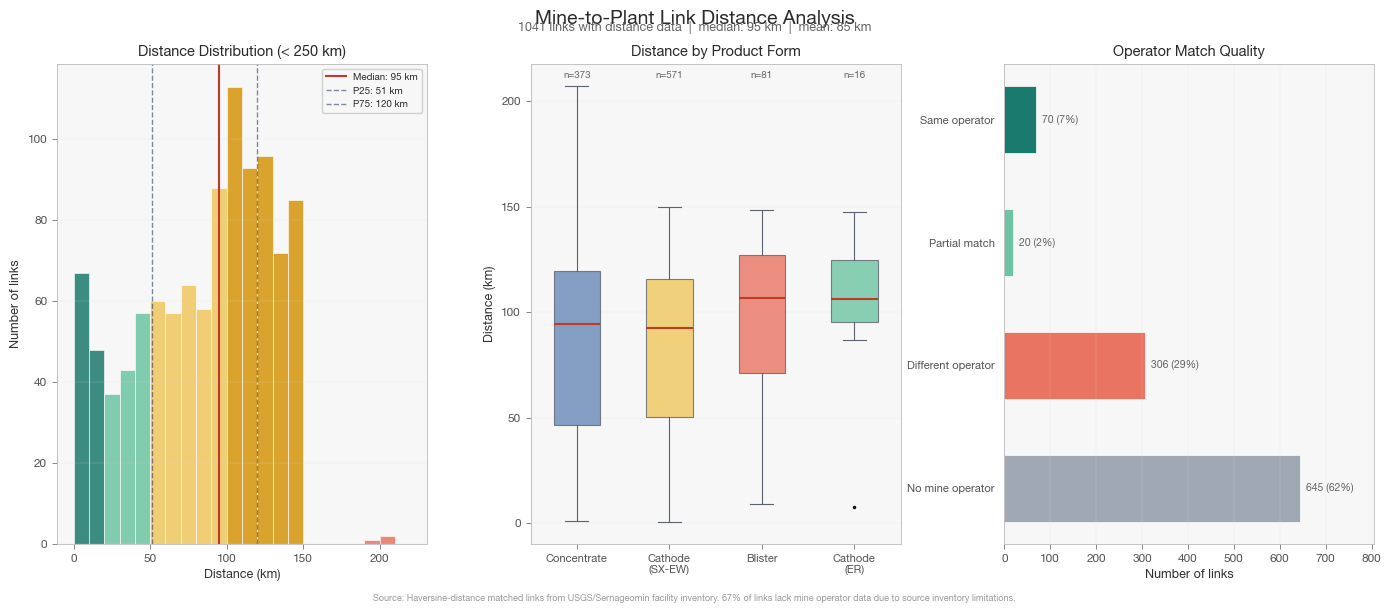


ALL FIGURES SAVED
  Missing_Data_Analysis.png
  Cu_Production_Concentration.png
  Supply_Chain_Structure.png
  Export_Destination_Profile.png
  Link_Distance_Quality.png


In [13]:
# %% 5. Link distance quality

m2p = links.copy()
m2p["DISTANCE_KM"] = pd.to_numeric(m2p["DISTANCE_KM"], errors="coerce")
m2p = m2p[m2p["DISTANCE_KM"].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(17, 6),
                         gridspec_kw={"width_ratios": [1.0, 1.0, 1.0], "wspace": 0.28})
fig.suptitle("Mine-to-Plant Link Distance Analysis",
             fontsize=14, fontweight="bold", y=0.99, color=PAL["text"])
fig.text(0.5, 0.955,
         f"{len(m2p)} links with distance data  |  "
         f"median: {m2p['DISTANCE_KM'].median():.0f} km  |  "
         f"mean: {m2p['DISTANCE_KM'].mean():.0f} km",
         ha="center", fontsize=9, color=PAL["text_sec"])

# ── Panel A: Distance distribution ────────────────────────────────────────
ax = axes[0]
dist_vals = m2p["DISTANCE_KM"].values
bins = np.arange(0, min(dist_vals.max() + 20, 250), 10)

n, bin_edges, patches = ax.hist(dist_vals[dist_vals < 250], bins=bins,
                                 color=PAL["navy_lt"], edgecolor="white",
                                 linewidth=0.5, alpha=0.85)
# Color code by distance quality
for patch, left_edge in zip(patches, bin_edges):
    if left_edge < 20:
        patch.set_facecolor(PAL["teal"])
    elif left_edge < 50:
        patch.set_facecolor(PAL["teal_lt"])
    elif left_edge < 100:
        patch.set_facecolor(PAL["amber_lt"])
    elif left_edge < 150:
        patch.set_facecolor(PAL["amber"])
    else:
        patch.set_facecolor(PAL["brick_lt"])

# Percentile markers
med = np.median(dist_vals)
p25 = np.percentile(dist_vals, 25)
p75 = np.percentile(dist_vals, 75)
ax.axvline(med, color=PAL["brick"], linewidth=1.5, linestyle="-", label=f"Median: {med:.0f} km")
ax.axvline(p25, color=PAL["navy"], linewidth=1, linestyle="--", alpha=0.6, label=f"P25: {p25:.0f} km")
ax.axvline(p75, color=PAL["navy"], linewidth=1, linestyle="--", alpha=0.6, label=f"P75: {p75:.0f} km")

ax.set_xlabel("Distance (km)")
ax.set_ylabel("Number of links")
ax.set_title("Distance Distribution (< 250 km)")
ax.legend(fontsize=7, framealpha=0.9, edgecolor="#cccccc")
ax.grid(axis="y", alpha=0.4)

# ── Panel B: Distance by product form ─────────────────────────────────────
ax = axes[1]
if "PRODUCT_FORM" in m2p.columns:
    pf_order = ["concentrate", "cathode_sxew", "blister", "cathode_er"]
    pf_data = [m2p[m2p["PRODUCT_FORM"] == pf]["DISTANCE_KM"].values
               for pf in pf_order if pf in m2p["PRODUCT_FORM"].values]
    pf_labels_box = [pf for pf in pf_order if pf in m2p["PRODUCT_FORM"].values]
    pf_display = {"concentrate": "Concentrate", "cathode_sxew": "Cathode\n(SX-EW)",
                  "blister": "Blister", "cathode_er": "Cathode\n(ER)"}

    bp = ax.boxplot(pf_data, patch_artist=True, widths=0.5,
                    medianprops=dict(color=PAL["brick"], linewidth=1.5),
                    whiskerprops=dict(color=PAL["slate"], linewidth=0.8),
                    capprops=dict(color=PAL["slate"], linewidth=0.8),
                    flierprops=dict(marker=".", markersize=3, markerfacecolor=PAL["slate_lt"]))

    box_colors = [PAL["navy_lt"], PAL["amber_lt"], PAL["brick_lt"], PAL["teal_lt"]]
    for patch, color in zip(bp["boxes"], box_colors[:len(bp["boxes"])]):
        patch.set_facecolor(color)
        patch.set_edgecolor(PAL["slate"])
        patch.set_linewidth(0.8)
        patch.set_alpha(0.8)

    ax.set_xticklabels([pf_display.get(l, l) for l in pf_labels_box], fontsize=8)
    ax.set_ylabel("Distance (km)")
    ax.set_title("Distance by Product Form")
    ax.grid(axis="y", alpha=0.4)

    # Add counts
    for i, (data, label) in enumerate(zip(pf_data, pf_labels_box)):
        ax.text(i+1, ax.get_ylim()[1]*0.97, f"n={len(data)}",
                ha="center", fontsize=7, color=PAL["text_sec"])

# ── Panel C: Operator match quality ───────────────────────────────────────
ax = axes[2]
if "MINE_OPERATOR" in m2p.columns and "PLANT_OPERATOR" in m2p.columns:
    def classify_op(row):
        mine_op  = str(row.get("MINE_OPERATOR", "")).strip()
        plant_op = str(row.get("PLANT_OPERATOR", "")).strip()
        if not mine_op or mine_op == "nan":
            return "No mine operator"
        if not plant_op or plant_op == "nan":
            return "No plant operator"
        if mine_op.lower() == plant_op.lower():
            return "Same operator"
        if mine_op.lower()[:8] in plant_op.lower() or plant_op.lower()[:8] in mine_op.lower():
            return "Partial match"
        return "Different operator"

    m2p["_op_class"] = m2p.apply(classify_op, axis=1)
    op_order = ["Same operator", "Partial match", "Different operator",
                "No mine operator", "No plant operator"]
    op_colors_map = {
        "Same operator":      PAL["teal"],
        "Partial match":      PAL["teal_lt"],
        "Different operator": PAL["brick_lt"],
        "No mine operator":   PAL["slate_lt"],
        "No plant operator":  PAL["slate"],
    }

    op_counts = m2p["_op_class"].value_counts()
    present_ops = [o for o in op_order if o in op_counts.index]
    vals_op = [op_counts[o] for o in present_ops]
    cols_op = [op_colors_map.get(o, PAL["slate"]) for o in present_ops]

    bars = ax.barh(range(len(present_ops)), vals_op, color=cols_op,
                   edgecolor="white", linewidth=0.5, height=0.55)
    ax.set_yticks(range(len(present_ops)))
    ax.set_yticklabels(present_ops, fontsize=8)
    for i, val in enumerate(vals_op):
        pct = val / len(m2p) * 100
        ax.text(val + max(vals_op)*0.02, i,
                f"{val} ({pct:.0f}%)", va="center", fontsize=7.5, color=PAL["text_sec"])
    ax.set_xlim(0, max(vals_op) * 1.25)
    ax.set_title("Operator Match Quality")
    ax.set_xlabel("Number of links")
    ax.grid(axis="x", alpha=0.4)
    ax.tick_params(left=False)
    ax.invert_yaxis()

plt.subplots_adjust(top=0.90, bottom=0.10)
add_source_note(fig,
    "Source: Haversine-distance matched links from USGS/Sernageomin facility inventory. "
    "67% of links lack mine operator data due to source inventory limitations.")

out5 = os.path.join(OUT_DIR, "Link_Distance_Quality.png")
fig.savefig(out5, dpi=200, bbox_inches="tight")
print(f"Saved: {out5}")
plt.show()

print("\n" + "="*60)
print("ALL FIGURES SAVED")
print("="*60)
for p in [out1, out2, out3, out4, out5]:
    print(f"  {os.path.basename(p)}")
if os.path.exists(os.path.join(OUT_DIR, "Chile_Supply_Chain_Map.html")):
    print("  Chile_Supply_Chain_Map.html")
for extra in ["Port_Share_Comparison.png", "Comtrade_Validation.png"]:
    if os.path.exists(os.path.join(OUT_DIR, extra)):
        print(f"  {extra}")


In [ ]:
# %% 6. Geographic supply chain map

import folium
from folium import plugins

# ── Build interactive map ────────────────────────────────────────────────

m = folium.Map(location=[-26.0, -70.0], zoom_start=5,
               tiles="cartodbpositron", width="100%", height="100%")

# Color scheme
STAGE_COLORS = {
    "extraction": "#2c3e6b", "extraction_idle": "#a0a8b4",
    "concentration": "#6c3483", "sx_ew": "#d4940a",
    "smelting": "#c0392b", "refining": "#e87461",
    "processing": "#1b7a6e", "other": "#7f8c8d",
}
EDGE_COLORS = {
    "mine_to_plant":          "#2c3e6b",
    "concentrate_to_port":    "#6c3483",
    "concentrate_to_smelter": "#c0392b",
    "sxew_to_port":           "#d4940a",
    "smelter_to_port":        "#e87461",
    "port_to_country":        "#1b7a6e",
}

# ── Plot facilities ──────────────────────────────────────────────────────
stage_col = "CHAIN_STAGE" if "CHAIN_STAGE" in inv.columns else None
for _, row in inv[inv["LATITUD"].notna()].iterrows():
    stage = row.get(stage_col, "other") if stage_col else "other"
    color = STAGE_COLORS.get(stage, "#7f8c8d")
    cu_prod = row.get("COCHILCO_CU_2024_KMT", None)

    # Size by production
    if pd.notna(cu_prod) and cu_prod > 0:
        radius = max(4, min(18, cu_prod / 80))
    elif stage in ("extraction", "extraction_idle"):
        radius = 3
    else:
        radius = 2.5

    popup_lines = [
        f"<b>{row['FACILITY_NAME']}</b>",
        f"Type: {row['FACILITY_TYPE']}",
        f"Stage: {stage}",
    ]
    if pd.notna(cu_prod) and cu_prod > 0:
        popup_lines.append(f"Cu production: {cu_prod:,.1f} kMT")
    op = row.get("OPERATOR_NAME", "")
    if pd.notna(op) and op:
        popup_lines.append(f"Operator: {op}")

    folium.CircleMarker(
        location=[row["LATITUD"], row["LONGITUD"]],
        radius=radius,
        color=color, fill=True, fill_color=color, fill_opacity=0.7,
        weight=0.8, opacity=0.9,
        popup=folium.Popup("<br>".join(popup_lines), max_width=250),
    ).add_to(m)

# ── Plot ports ───────────────────────────────────────────────────────────
for _, p in ports.iterrows():
    folium.Marker(
        location=[p["lat"], p["lon"]],
        icon=folium.Icon(color="darkblue", icon="anchor", prefix="fa"),
        popup=folium.Popup(
            f"<b>{p['name']}</b><br>Region: {p['region']}<br>Products: {p['products']}",
            max_width=250),
    ).add_to(m)

# ── Plot domestic supply chain edges ─────────────────────────────────────
domestic_types = ["mine_to_plant", "concentrate_to_port", "sxew_to_port",
                  "smelter_to_port", "concentrate_to_smelter"]

for _, e in edges[edges["EDGE_TYPE"].isin(domestic_types)].iterrows():
    if pd.isna(e.get("FROM_LAT")) or pd.isna(e.get("TO_LAT")):
        continue
    color = EDGE_COLORS.get(e["EDGE_TYPE"], "#999999")
    weight = 1.0 if e["EDGE_TYPE"] == "mine_to_plant" else 2.0
    opacity = 0.25 if e["EDGE_TYPE"] == "mine_to_plant" else 0.6

    folium.PolyLine(
        locations=[[e["FROM_LAT"], e["FROM_LON"]], [e["TO_LAT"], e["TO_LON"]]],
        color=color, weight=weight, opacity=opacity,
        popup=f"{e['EDGE_TYPE']}: {e['FROM_NAME']} -> {e['TO_NAME']}",
    ).add_to(m)

# ── Legend ────────────────────────────────────────────────────────────────
legend_html = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:white; padding:12px 16px; border-radius:6px;
     border:1px solid #ccc; font-size:11px; line-height:1.6; max-width:200px;">
<b>Facility Stage</b><br>
<span style="color:#2c3e6b;">&#9679;</span> Extraction &nbsp;
<span style="color:#6c3483;">&#9679;</span> Concentration<br>
<span style="color:#d4940a;">&#9679;</span> SX-EW &nbsp;
<span style="color:#c0392b;">&#9679;</span> Smelting<br>
<span style="color:#1b7a6e;">&#9679;</span> Processing &nbsp;
<span style="color:#a0a8b4;">&#9679;</span> Idle<br>
<b style="margin-top:6px; display:block;">Edge Type</b>
<span style="color:#2c3e6b;">&#9135;</span> Mine-Plant &nbsp;
<span style="color:#6c3483;">&#9135;</span> Conc-Port<br>
<span style="color:#d4940a;">&#9135;</span> SX-EW-Port &nbsp;
<span style="color:#e87461;">&#9135;</span> Smelter-Port
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Save
map_path = os.path.join(OUT_DIR, "Chile_Supply_Chain_Map.html")
m.save(map_path)
print(f"Saved: {map_path}")
m

In [ ]:
# %% 7. Port comparison and Comtrade cross-validation

# ── Figure 7A: Port shares comparison ────────────────────────────────────

comp_path = os.path.join(PRELIM, "Port_Distance_Comparison.csv")
if os.path.exists(comp_path):
    comp = pd.read_csv(comp_path)
    products = [p for p in ["concentrate", "cathode", "blister"] if p in comp["product"].unique()]

    fig, axes = plt.subplots(1, len(products), figsize=(7*len(products), 7),
                             gridspec_kw={"wspace": 0.30})
    if len(products) == 1:
        axes = [axes]
    fig.suptitle("Port Share Comparison: Actual (Aduanas) vs Modelled",
                 fontsize=14, fontweight="bold", y=1.02, color=PAL["text"])

    for idx, product in enumerate(products):
        ax = axes[idx]
        sub = comp[comp["product"] == product].copy()
        sub = sub.sort_values("actual_share", ascending=False)
        sub = sub[(sub["actual_share"] >= 0.01) | (sub["simulated_share"] >= 0.01)].head(10)

        x = np.arange(len(sub))
        width = 0.35
        ax.bar(x - width/2, sub["actual_share"] * 100, width,
               label="Actual (Aduanas)", color=PAL["brick_lt"], edgecolor="white", linewidth=0.5)
        ax.bar(x + width/2, sub["simulated_share"] * 100, width,
               label="Modelled", color=PAL["teal"], edgecolor="white", linewidth=0.5)

        ax.set_xticks(x)
        ax.set_xticklabels(sub["port"], rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("Share (%)")
        ax.set_title(f"{product.upper()}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=7.5, framealpha=0.9, edgecolor="#cccccc")
        ax.grid(axis="y", alpha=0.4)

        # Annotate total mismatch
        mad = sub["difference"].abs().mean() * 100
        ax.text(0.98, 0.95, f"MAD: {mad:.1f}%", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color=PAL["text_sec"],
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#ccc"))

    add_source_note(fig, "Source: Aduanas Salidas FOB shares vs model (dedicated overrides + Codelco routing + distance)")
    out7a = os.path.join(OUT_DIR, "Port_Share_Comparison.png")
    fig.savefig(out7a, dpi=200, bbox_inches="tight")
    print(f"Saved: {out7a}")
    plt.show()
else:
    print("Port_Distance_Comparison.csv not found, skipping port comparison chart")

# ── Figure 7B: Comtrade cross-validation ─────────────────────────────────

comtrade_val_path = os.path.join(PRELIM, "Comtrade_vs_Salidas_Validation.csv")
if os.path.exists(comtrade_val_path):
    cv = pd.read_csv(comtrade_val_path, index_col=0)
    cv = cv[(cv["ct_fob"] > 0) | (cv["sal_fob"] > 0)].copy()
    cv = cv.sort_values("ct_fob", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7),
                             gridspec_kw={"width_ratios": [1.2, 1.0], "wspace": 0.35})
    fig.suptitle("Comtrade vs Aduanas Salidas: Cross-Validation",
                 fontsize=14, fontweight="bold", y=1.01, color=PAL["text"])

    # Panel A: FOB comparison bar chart
    ax = axes[0]
    y = np.arange(len(cv))
    height = 0.35
    ax.barh(y - height/2, cv["ct_fob"] / 1e9, height,
            label="Comtrade", color=PAL["navy"], edgecolor="white", linewidth=0.5)
    ax.barh(y + height/2, cv["sal_fob"] / 1e9, height,
            label="Aduanas Salidas", color=PAL["amber"], edgecolor="white", linewidth=0.5)
    ax.set_yticks(y)
    ax.set_yticklabels(cv.index, fontsize=8)
    ax.set_xlabel("FOB Value (billion USD)")
    ax.set_title("FOB Comparison by Commodity")
    ax.legend(fontsize=8, framealpha=0.9, edgecolor="#cccccc")
    ax.grid(axis="x", alpha=0.4)
    ax.tick_params(left=False)

    # Panel B: Ratio scatter
    ax = axes[1]
    cv_with_ratio = cv[cv["fob_ratio"].notna() & (cv["fob_ratio"] > 0)].copy()
    colors_scatter = [PAL["teal"] if 0.8 <= r <= 1.2 else PAL["brick"]
                      for r in cv_with_ratio["fob_ratio"]]
    sizes = np.clip(cv_with_ratio["ct_fob"] / 1e9 * 15, 30, 300)

    ax.scatter(cv_with_ratio["ct_fob"] / 1e9, cv_with_ratio["fob_ratio"],
               c=colors_scatter, s=sizes, edgecolors="white", linewidths=0.8, alpha=0.85, zorder=3)
    ax.axhline(1.0, color=PAL["slate_lt"], linestyle="-", linewidth=1, alpha=0.6)
    ax.axhspan(0.8, 1.2, color=PAL["teal_lt"], alpha=0.1, label="Within 20%")

    for _, row in cv_with_ratio.iterrows():
        ax.annotate(row.name, (row["ct_fob"]/1e9, row["fob_ratio"]),
                    textcoords="offset points", xytext=(6, 4),
                    fontsize=7, color=PAL["text_sec"])

    ax.set_xlabel("Comtrade FOB (billion USD)")
    ax.set_ylabel("Salidas / Comtrade Ratio")
    ax.set_title("Coverage Ratio by Commodity")
    ax.legend(fontsize=7.5, framealpha=0.9, edgecolor="#cccccc", loc="upper left")
    ax.grid(alpha=0.4)

    add_source_note(fig, "Source: UN Comtrade HS6 (2024) vs Chilean Aduanas Salidas export data")
    out7b = os.path.join(OUT_DIR, "Comtrade_Validation.png")
    fig.savefig(out7b, dpi=200, bbox_inches="tight")
    print(f"Saved: {out7b}")
    plt.show()
else:
    print("Comtrade_vs_Salidas_Validation.csv not found, skipping validation chart")